<a href="https://colab.research.google.com/github/Deva200612/AI-Based-Responsive-Chatbot/blob/main/Explainable_AI_Based_Heart_Disease_Risk_Prediction_Web_Application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!pip -q install ucimlrepo shap flask

In [35]:
import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

# Load dataset
heart = fetch_ucirepo(id=45)

X = heart.data.features
y = heart.data.targets

print("Dataset loaded successfully")
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

Dataset loaded successfully
X shape: (303, 13)
y shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [36]:
# Convert target to binary

target = y.iloc[:, 0]

target = pd.to_numeric(target, errors="coerce")

target = (target > 0).astype(int)

print(target.value_counts())

num
0    164
1    139
Name: count, dtype: int64


In [37]:
# Copy dataset
data = X.copy()

# Replace ? with NaN
data = data.replace("?", np.nan)

# Convert all columns to numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

print(data.dtypes)
print("\nMissing values:")
print(data.isnull().sum())

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    probabilities = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    sensitivity = tp / (tp + fn)

    specificity = tn / (tn + fp)

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    results[name] = {
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "ROC-AUC": auc
    }

    print("\n", name)
    print("------------------------")
    print("Accuracy    :", round(accuracy * 100, 2), "%")
    print("Sensitivity :", round(sensitivity * 100, 2), "%")
    print("Specificity :", round(specificity * 100, 2), "%")
    print("ROC-AUC     :", round(auc, 3))


 Logistic Regression
------------------------
Accuracy    : 86.89 %
Sensitivity : 92.86 %
Specificity : 81.82 %
ROC-AUC     : 0.951

 Random Forest
------------------------
Accuracy    : 90.16 %
Sensitivity : 96.43 %
Specificity : 84.85 %
ROC-AUC     : 0.955

 SVM
------------------------
Accuracy    : 85.25 %
Sensitivity : 89.29 %
Specificity : 81.82 %
ROC-AUC     : 0.944


In [39]:
results_df = pd.DataFrame(results).T

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Sensitivity": "{:.2%}",
        "Specificity": "{:.2%}",
        "ROC-AUC": "{:.3f}"
    })
)

,Accuracy,Sensitivity,Specificity,ROC-AUC
Logistic Regression,86.89%,92.86%,81.82%,0.951
Random Forest,90.16%,96.43%,84.85%,0.955
SVM,85.25%,89.29%,81.82%,0.944


In [40]:
best_model_name = results_df["ROC-AUC"].idxmax()

print("Best Model:", best_model_name)

Best Model: Random Forest


In [41]:
best_model = models[best_model_name]

best_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)


# Example patient
patient = pd.DataFrame([{
    "age": 55,
    "sex": 1,
    "cp": 2,
    "trestbps": 140,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 1,
    "ca": 0,
    "thal": 2
}])

prediction = best_pipeline.predict(patient)[0]

probability = best_pipeline.predict_proba(patient)[0][1]

print("Prediction:", prediction)
print("Disease Probability:", round(probability * 100, 2), "%")

Prediction: 0
Disease Probability: 13.5 %


In [42]:
if probability < 0.33:
    risk = "LOW"
elif probability < 0.66:
    risk = "MEDIUM"
else:
    risk = "HIGH"

print("Predicted Risk:", risk)

Predicted Risk: LOW


In [43]:
!pip install -q shap

In [44]:
import shap
import matplotlib.pyplot as plt

# Get the actual trained ML model
model = best_pipeline.named_steps["model"]

# Preprocess training and test data
X_train_processed = best_pipeline.named_steps["imputer"].transform(X_train)
X_train_processed = best_pipeline.named_steps["scaler"].transform(X_train_processed)

X_test_processed = best_pipeline.named_steps["imputer"].transform(X_test)
X_test_processed = best_pipeline.named_steps["scaler"].transform(X_test_processed)

print("SHAP data prepared successfully")

SHAP data prepared successfully


In [45]:
if best_model_name == "Random Forest":

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(
        X_test_processed
    )

else:

    # For Logistic Regression / SVM
    background = shap.sample(
        X_train_processed,
        50,
        random_state=42
    )

    explainer = shap.KernelExplainer(
        model.predict_proba,
        background
    )

    # Small number of samples to reduce processing time
    shap_values = explainer.shap_values(
        X_test_processed[:30]
    )

print("SHAP explanation generated")

SHAP explanation generated


<Figure size 640x480 with 0 Axes>

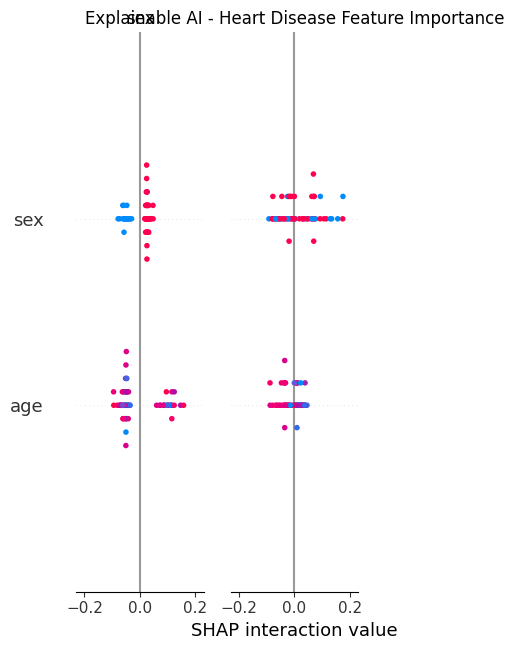

In [46]:
# Handle different SHAP output formats

if isinstance(shap_values, list):

    # Binary classification
    shap_plot_values = shap_values[1]

else:

    shap_plot_values = shap_values


plt.figure()

shap.summary_plot(
    shap_plot_values,
    X_test_processed[:len(shap_plot_values)],
    feature_names=data.columns,
    show=False
)

plt.title(
    "Explainable AI - Heart Disease Feature Importance"
)

plt.tight_layout()

plt.show()

In [47]:
# STEP 14 - FIXED SHAP FEATURE IMPORTANCE

import numpy as np
import pandas as pd

# Convert SHAP values to numpy array
shap_array = np.asarray(shap_plot_values)

print("SHAP shape:", shap_array.shape)
print("Number of features:", len(data.columns))

# Make sure SHAP values are in (samples, features) format
if shap_array.ndim == 3:
    # For some SHAP versions:
    # (samples, features, classes)
    shap_array = shap_array[:, :, 1]

elif shap_array.ndim == 1:
    shap_array = shap_array.reshape(1, -1)

# Calculate mean absolute SHAP importance
importance = np.mean(
    np.abs(shap_array),
    axis=0
)

# Make sure number of values matches number of features
if len(importance) != len(data.columns):

    print(
        "Feature mismatch:",
        len(importance),
        "SHAP values vs",
        len(data.columns),
        "features"
    )

else:

    feature_importance = pd.DataFrame({
        "Feature": data.columns,
        "Importance": importance
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nTop 10 Important Features:")

    display(
        feature_importance.head(10)
    )

SHAP shape: (61, 13, 2)
Number of features: 13

Top 10 Important Features:


,Feature,Importance
12,thal,0.108639
11,ca,0.098258
2,cp,0.083433
9,oldpeak,0.052528
7,thalach,0.044267
8,exang,0.041339
1,sex,0.035672
10,slope,0.034684
0,age,0.028304
4,chol,0.019320


In [48]:
# TOP 5 FEATURES

top_5 = feature_importance.head(5)

display(top_5)

,Feature,Importance
12,thal,0.108639
11,ca,0.098258
2,cp,0.083433
9,oldpeak,0.052528
7,thalach,0.044267


In [49]:
# ============================================================
# STEP 15 - PATIENT SHAP EXPLANATION
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Transform patient using the same preprocessing
# ------------------------------------------------------------

patient_processed = best_pipeline.named_steps["imputer"].transform(
    patient
)

patient_processed = best_pipeline.named_steps["scaler"].transform(
    patient_processed
)

print("Patient processed shape:", patient_processed.shape)


# ------------------------------------------------------------
# 2. Generate SHAP values
# ------------------------------------------------------------

patient_shap = explainer.shap_values(patient_processed)

print("SHAP output type:", type(patient_shap))


# ------------------------------------------------------------
# 3. Handle different SHAP output formats
# ------------------------------------------------------------

if isinstance(patient_shap, list):

    print("SHAP list length:", len(patient_shap))

    # Binary classification
    if len(patient_shap) > 1:
        patient_values = np.asarray(patient_shap[1])
    else:
        patient_values = np.asarray(patient_shap[0])

else:

    patient_values = np.asarray(patient_shap)


# ------------------------------------------------------------
# 4. Remove unnecessary dimensions
# ------------------------------------------------------------

patient_values = np.squeeze(patient_values)

print("SHAP shape after squeeze:", patient_values.shape)


# ------------------------------------------------------------
# 5. Handle 3D SHAP output
# ------------------------------------------------------------

if patient_values.ndim == 3:

    # samples × features × classes
    patient_values = patient_values[0, :, 1]


# ------------------------------------------------------------
# 6. Handle 2D SHAP output
# ------------------------------------------------------------

elif patient_values.ndim == 2:

    patient_values = patient_values[0]


# ------------------------------------------------------------
# 7. Make sure SHAP values are 1D
# ------------------------------------------------------------

patient_values = np.asarray(
    patient_values
).flatten()


print("Final SHAP values:", len(patient_values))

print(
    "Dataset features:",
    len(data.columns)
)


# ------------------------------------------------------------
# 8. Create explanation table
# ------------------------------------------------------------

if len(patient_values) == len(data.columns):

    patient_explanation = pd.DataFrame({

        "Feature": data.columns,

        "SHAP Contribution": patient_values

    })


    # Absolute impact
    patient_explanation["Absolute Impact"] = (
        patient_explanation["SHAP Contribution"].abs()
    )


    # Sort by importance
    patient_explanation = patient_explanation.sort_values(
        by="Absolute Impact",
        ascending=False
    )


    print("\nTop factors affecting this patient's prediction:")

    display(
        patient_explanation[
            [
                "Feature",
                "SHAP Contribution"
            ]
        ].head(10)
    )


else:

    print(
        "ERROR: SHAP value count does not match "
        "dataset feature count."
    )

    print(
        "SHAP values:",
        len(patient_values)
    )

    print(
        "Features:",
        len(data.columns)
    )

Patient processed shape: (1, 13)
SHAP output type: <class 'numpy.ndarray'>
SHAP shape after squeeze: (13, 2)
Final SHAP values: 2
Dataset features: 13
ERROR: SHAP value count does not match dataset feature count.
SHAP values: 2
Features: 13


In [50]:
# ============================================================
# STEP 16 - SAVE TRAINED MODEL
# ============================================================

import joblib

# Save complete pipeline
joblib.dump(
    best_pipeline,
    "/content/heart_disease_model.pkl"
)

# Save SHAP explainer
joblib.dump(
    explainer,
    "/content/shap_explainer.pkl"
)

print("Model saved successfully!")
print("SHAP explainer saved successfully!")

Model saved successfully!
SHAP explainer saved successfully!


In [51]:
# ============================================================
# STEP 17 - CHECK SAVED FILES
# ============================================================

import os

print("Checking saved files...\n")

if os.path.exists("/content/heart_disease_model.pkl"):
    print("✓ heart_disease_model.pkl")

if os.path.exists("/content/shap_explainer.pkl"):
    print("✓ shap_explainer.pkl")

Checking saved files...

✓ heart_disease_model.pkl
✓ shap_explainer.pkl


In [52]:
# ============================================================
# STEP 18 - INSTALL FLASK
# ============================================================

!pip install flask pyngrok -q

print("Flask installed successfully!")

Flask installed successfully!


In [53]:
# ============================================================
# STEP 19 - CREATE FLASK APP
# ============================================================

from flask import Flask, render_template, request
import joblib
import pandas as pd
import numpy as np

app = Flask(__name__)

# Load trained model
model = joblib.load(
    "/content/heart_disease_model.pkl"
)

# Load SHAP explainer
explainer = joblib.load(
    "/content/shap_explainer.pkl"
)

print("Flask app created successfully!")
print("Model loaded successfully!")
print("SHAP explainer loaded successfully!")

Flask app created successfully!
Model loaded successfully!
SHAP explainer loaded successfully!


In [54]:
# ============================================================
# STEP 20 - CREATE WEBSITE FOLDERS
# ============================================================

import os

os.makedirs(
    "/content/templates",
    exist_ok=True
)

os.makedirs(
    "/content/static",
    exist_ok=True
)

print("Website folders created successfully!")

Website folders created successfully!


In [55]:
# ============================================================
# STEP 21 - CREATE HOME PAGE
# ============================================================

home_html = """
<!DOCTYPE html>

<html>

<head>

    <title>Heart Disease Risk Prediction</title>

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <style>

        * {
            box-sizing: border-box;
            margin: 0;
            padding: 0;
        }

        body {
            font-family: Arial, sans-serif;
            background: #f5f8fc;
            color: #1f2937;
        }

        .navbar {
            background: #ffffff;
            padding: 20px 8%;
            display: flex;
            justify-content: space-between;
            align-items: center;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        }

        .logo {
            font-size: 22px;
            font-weight: bold;
            color: #2563eb;
        }

        .hero {
            min-height: 80vh;
            display: flex;
            align-items: center;
            justify-content: center;
            padding: 50px 8%;
        }

        .hero-content {
            max-width: 850px;
            text-align: center;
        }

        .hero h1 {
            font-size: 46px;
            margin-bottom: 20px;
            color: #111827;
        }

        .hero h1 span {
            color: #2563eb;
        }

        .hero p {
            font-size: 18px;
            line-height: 1.7;
            color: #6b7280;
            margin-bottom: 30px;
        }

        .button {
            display: inline-block;
            padding: 15px 30px;
            background: #2563eb;
            color: white;
            text-decoration: none;
            border-radius: 8px;
            font-size: 17px;
            font-weight: bold;
        }

        .button:hover {
            background: #1d4ed8;
        }

        .features {
            display: flex;
            justify-content: center;
            gap: 20px;
            margin-top: 45px;
            flex-wrap: wrap;
        }

        .card {
            background: white;
            width: 250px;
            padding: 25px;
            border-radius: 12px;
            box-shadow: 0 3px 15px rgba(0,0,0,0.08);
        }

        .card h3 {
            margin-bottom: 10px;
            color: #2563eb;
        }

        .card p {
            font-size: 14px;
            margin: 0;
        }

        .disclaimer {
            text-align: center;
            padding: 20px;
            font-size: 13px;
            color: #6b7280;
        }

    </style>

</head>


<body>

    <div class="navbar">

        <div class="logo">
            HeartAI
        </div>

        <div>
            Explainable AI
        </div>

    </div>


    <section class="hero">

        <div class="hero-content">

            <h1>
                Heart Disease
                <span>Risk Prediction</span>
            </h1>

            <p>
                An Explainable Artificial Intelligence based
                web application for predicting heart disease
                risk using machine learning and explaining
                the factors influencing the prediction.
            </p>


            <a href="/predict" class="button">
                Start Prediction
            </a>


            <div class="features">

                <div class="card">

                    <h3>
                        AI Prediction
                    </h3>

                    <p>
                        Machine learning models analyze
                        the provided health-related inputs.
                    </p>

                </div>


                <div class="card">

                    <h3>
                        Explainable AI
                    </h3>

                    <p>
                        SHAP helps explain which input
                        features influenced the prediction.
                    </p>

                </div>


                <div class="card">

                    <h3>
                        Risk Assessment
                    </h3>

                    <p>
                        The prototype provides a
                        model-based risk category.
                    </p>

                </div>

            </div>

        </div>

    </section>


    <div class="disclaimer">

        Academic prototype for educational purposes.
        This application is not a medical diagnostic tool.

    </div>


</body>

</html>
"""


# Save HTML file

with open(
    "/content/templates/index.html",
    "w"
) as file:

    file.write(home_html)


print("Home page created successfully!")

Home page created successfully!


In [56]:
# ============================================================
# STEP 22 - HOME PAGE ROUTE
# ============================================================

@app.route("/")
def home():

    return render_template(
        "index.html"
    )


print("Home page route created successfully!")

Home page route created successfully!


In [57]:
# ============================================================
# STEP 23 - CREATE PREDICTION PAGE
# ============================================================

predict_html = """
<!DOCTYPE html>

<html>

<head>

    <title>Heart Disease Prediction</title>

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <style>

        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f5f8fc;
            color: #1f2937;
        }

        .navbar {
            background: white;
            padding: 20px 8%;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        }

        .logo {
            font-size: 22px;
            font-weight: bold;
            color: #2563eb;
        }

        .container {
            max-width: 900px;
            margin: 40px auto;
            padding: 20px;
        }

        .form-card {
            background: white;
            padding: 35px;
            border-radius: 15px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.08);
        }

        h1 {
            text-align: center;
            margin-bottom: 10px;
        }

        .subtitle {
            text-align: center;
            color: #6b7280;
            margin-bottom: 30px;
        }

        .form-grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 20px;
        }

        .form-group {
            display: flex;
            flex-direction: column;
        }

        label {
            margin-bottom: 7px;
            font-weight: bold;
        }

        input,
        select {
            padding: 12px;
            border: 1px solid #d1d5db;
            border-radius: 7px;
            font-size: 15px;
        }

        .full-width {
            grid-column: 1 / -1;
        }

        .button-container {
            text-align: center;
            margin-top: 30px;
        }

        button {
            padding: 14px 35px;
            border: none;
            border-radius: 8px;
            background: #2563eb;
            color: white;
            font-size: 17px;
            font-weight: bold;
            cursor: pointer;
        }

        button:hover {
            background: #1d4ed8;
        }

        .note {
            margin-top: 25px;
            padding: 15px;
            background: #eff6ff;
            border-radius: 8px;
            font-size: 13px;
            color: #374151;
        }

        @media(max-width: 700px) {

            .form-grid {
                grid-template-columns: 1fr;
            }

            .full-width {
                grid-column: auto;
            }

        }

    </style>

</head>


<body>

    <div class="navbar">

        <div class="logo">
            HeartAI
        </div>

    </div>


    <div class="container">

        <div class="form-card">

            <h1>
                Heart Disease Risk Prediction
            </h1>

            <p class="subtitle">
                Enter the required information below
            </p>


            <form action="/predict" method="POST">

                <div class="form-grid">


                    <!-- Age -->

                    <div class="form-group">

                        <label>
                            Age
                        </label>

                        <input
                            type="number"
                            name="age"
                            min="1"
                            max="120"
                            required
                        >

                    </div>


                    <!-- Sex -->

                    <div class="form-group">

                        <label>
                            Sex
                        </label>

                        <select name="sex" required>

                            <option value="">
                                Select
                            </option>

                            <option value="1">
                                Male
                            </option>

                            <option value="0">
                                Female
                            </option>

                        </select>

                    </div>


                    <!-- Chest Pain -->

                    <div class="form-group">

                        <label>
                            Chest Pain Type
                        </label>

                        <select name="cp" required>

                            <option value="">
                                Select
                            </option>

                            <option value="0">
                                Typical Angina
                            </option>

                            <option value="1">
                                Atypical Angina
                            </option>

                            <option value="2">
                                Non-anginal Pain
                            </option>

                            <option value="3">
                                Asymptomatic
                            </option>

                        </select>

                    </div>


                    <!-- Blood Pressure -->

                    <div class="form-group">

                        <label>
                            Resting Blood Pressure
                        </label>

                        <input
                            type="number"
                            name="trestbps"
                            min="50"
                            max="250"
                            required
                        >

                    </div>


                    <!-- Cholesterol -->

                    <div class="form-group">

                        <label>
                            Cholesterol
                        </label>

                        <input
                            type="number"
                            name="chol"
                            min="50"
                            max="700"
                            required
                        >

                    </div>


                    <!-- Blood Sugar -->

                    <div class="form-group">

                        <label>
                            Fasting Blood Sugar
                        </label>

                        <select name="fbs" required>

                            <option value="0">
                                ≤ 120 mg/dl
                            </option>

                            <option value="1">
                                > 120 mg/dl
                            </option>

                        </select>

                    </div>


                    <!-- Rest ECG -->

                    <div class="form-group">

                        <label>
                            Resting ECG
                        </label>

                        <select name="restecg" required>

                            <option value="0">
                                Normal
                            </option>

                            <option value="1">
                                ST-T Wave Abnormality
                            </option>

                            <option value="2">
                                Left Ventricular Hypertrophy
                            </option>

                        </select>

                    </div>


                    <!-- Maximum Heart Rate -->

                    <div class="form-group">

                        <label>
                            Maximum Heart Rate
                        </label>

                        <input
                            type="number"
                            name="thalach"
                            min="50"
                            max="250"
                            required
                        >

                    </div>


                    <!-- Exercise Angina -->

                    <div class="form-group">

                        <label>
                            Exercise Induced Angina
                        </label>

                        <select name="exang" required>

                            <option value="0">
                                No
                            </option>

                            <option value="1">
                                Yes
                            </option>

                        </select>

                    </div>


                    <!-- Oldpeak -->

                    <div class="form-group">

                        <label>
                            ST Depression (Oldpeak)
                        </label>

                        <input
                            type="number"
                            name="oldpeak"
                            step="0.1"
                            min="0"
                            max="10"
                            required
                        >

                    </div>


                    <!-- Slope -->

                    <div class="form-group">

                        <label>
                            ST Segment Slope
                        </label>

                        <select name="slope" required>

                            <option value="0">
                                Upsloping
                            </option>

                            <option value="1">
                                Flat
                            </option>

                            <option value="2">
                                Downsloping
                            </option>

                        </select>

                    </div>


                    <!-- CA -->

                    <div class="form-group">

                        <label>
                            Number of Major Vessels (CA)
                        </label>

                        <select name="ca" required>

                            <option value="0">0</option>
                            <option value="1">1</option>
                            <option value="2">2</option>
                            <option value="3">3</option>

                        </select>

                    </div>


                    <!-- Thal -->

                    <div class="form-group">

                        <label>
                            Thalassemia Test (Thal)
                        </label>

                        <select name="thal" required>

                            <option value="1">
                                Normal
                            </option>

                            <option value="2">
                                Fixed Defect
                            </option>

                            <option value="3">
                                Reversible Defect
                            </option>

                        </select>

                    </div>


                </div>


                <div class="button-container">

                    <button type="submit">
                        Predict Risk
                    </button>

                </div>


                <div class="note">

                    <strong>Note:</strong>
                    This is an academic AI prototype.
                    The prediction is not a medical diagnosis
                    and should not replace professional medical advice.

                </div>


            </form>

        </div>

    </div>

</body>

</html>
"""


# Save prediction page

with open(
    "/content/templates/predict.html",
    "w"
) as file:

    file.write(predict_html)


print("Prediction page created successfully!")

Prediction page created successfully!


In [58]:
# ============================================================
# STEP 24 - PREDICTION PAGE ROUTE
# ============================================================

@app.route("/predict", methods=["GET"])
def prediction_page():

    return render_template(
        "predict.html"
    )


print("Prediction page route created successfully!")

Prediction page route created successfully!


In [59]:
# ============================================================
# STEP 25 - CONNECT PREDICTION FORM WITH ML MODEL
# ============================================================

@app.route("/predict", methods=["POST"])
def predict():

    # --------------------------------------------------------
    # Get values from HTML form
    # --------------------------------------------------------

    age = float(request.form["age"])
    sex = float(request.form["sex"])
    cp = float(request.form["cp"])
    trestbps = float(request.form["trestbps"])
    chol = float(request.form["chol"])
    fbs = float(request.form["fbs"])
    restecg = float(request.form["restecg"])
    thalach = float(request.form["thalach"])
    exang = float(request.form["exang"])
    oldpeak = float(request.form["oldpeak"])
    slope = float(request.form["slope"])
    ca = float(request.form["ca"])
    thal = float(request.form["thal"])


    # --------------------------------------------------------
    # Create patient DataFrame
    # --------------------------------------------------------

    patient_data = pd.DataFrame([{

        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal

    }])


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    prediction = model.predict(
        patient_data
    )[0]


    # --------------------------------------------------------
    # Probability
    # --------------------------------------------------------

    probability = model.predict_proba(
        patient_data
    )[0][1]


    # --------------------------------------------------------
    # Risk category
    # --------------------------------------------------------

    if probability < 0.33:

        risk_level = "LOW"

    elif probability < 0.66:

        risk_level = "MEDIUM"

    else:

        risk_level = "HIGH"


    # --------------------------------------------------------
    # Send result to result page
    # --------------------------------------------------------

    return render_template(
        "result.html",
        risk_level=risk_level,
        probability=round(probability * 100, 2),
        prediction=int(prediction),
        model_name=best_model_name
    )


print("Prediction backend created successfully!")

Prediction backend created successfully!


In [60]:
# ============================================================
# STEP 26 - CREATE RESULT PAGE
# ============================================================

result_html = """
<!DOCTYPE html>

<html>

<head>

    <title>Prediction Result</title>

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <style>

        * {
            box-sizing: border-box;
        }

        body {

            margin: 0;

            font-family: Arial, sans-serif;

            background: #f5f8fc;

            color: #1f2937;

        }


        .navbar {

            background: white;

            padding: 20px 8%;

            box-shadow: 0 2px 10px rgba(0,0,0,0.08);

        }


        .logo {

            font-size: 22px;

            font-weight: bold;

            color: #2563eb;

        }


        .container {

            max-width: 750px;

            margin: 60px auto;

            padding: 20px;

        }


        .result-card {

            background: white;

            padding: 40px;

            border-radius: 15px;

            text-align: center;

            box-shadow: 0 4px 20px rgba(0,0,0,0.08);

        }


        h1 {

            margin-bottom: 10px;

        }


        .subtitle {

            color: #6b7280;

            margin-bottom: 35px;

        }


        .risk {

            font-size: 38px;

            font-weight: bold;

            margin: 20px 0;

        }


        .probability {

            font-size: 24px;

            margin-bottom: 25px;

        }


        .model {

            color: #6b7280;

            margin-bottom: 30px;

        }


        .button {

            display: inline-block;

            padding: 13px 25px;

            background: #2563eb;

            color: white;

            text-decoration: none;

            border-radius: 8px;

            font-weight: bold;

        }


        .disclaimer {

            margin-top: 30px;

            padding: 15px;

            background: #eff6ff;

            border-radius: 8px;

            font-size: 13px;

            color: #374151;

        }

    </style>

</head>


<body>


    <div class="navbar">

        <div class="logo">

            HeartAI

        </div>

    </div>


    <div class="container">

        <div class="result-card">


            <h1>

                Prediction Result

            </h1>


            <p class="subtitle">

                AI-based model prediction

            </p>


            <div class="risk">

                {{ risk_level }}

            </div>


            <div class="probability">

                Risk Probability:

                <strong>

                    {{ probability }}%

                </strong>

            </div>


            <div class="model">

                Model Used:

                <strong>

                    {{ model_name }}

                </strong>

            </div>


            <a href="/predict" class="button">

                Predict Again

            </a>


            <div class="disclaimer">

                This result is generated by an academic

                machine learning prototype and is not a

                medical diagnosis. Please consult a qualified

                healthcare professional for medical advice.

            </div>


        </div>

    </div>


</body>

</html>
"""


# Save result page

with open(
    "/content/templates/result.html",
    "w"
) as file:

    file.write(result_html)


print("Result page created successfully!")

Result page created successfully!


In [61]:
# ============================================================
# STEP 27 - START FLASK SERVER
# ============================================================

from threading import Thread

def run_flask():

    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False,
        use_reloader=False
    )


flask_thread = Thread(
    target=run_flask
)

flask_thread.start()

print("Flask server started successfully!")

 * Serving Flask app '__main__'
 * Debug mode: off
Flask server started successfully!


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [62]:
# ============================================================
# STEP 28 - OPEN FLASK WEBSITE
# ============================================================

from google.colab import output

output.serve_kernel_port_as_iframe(
    5000,
    height=800
)

<IPython.core.display.Javascript object>